<a href="https://colab.research.google.com/github/LeDongPhuoc/DeepLC/blob/main/Master_Pipeline_A_to_Z.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TỔNG HỢP PIPELINE A-Z: YOLOv8 + MobileNetV2

Đây là file gộp toàn bộ quá trình từ chuẩn bị dữ liệu, huấn luyện 2 mô hình và kiểm thử thực tế. Bạn chỉ cần chạy từ trên xuống dưới trong **1 phiên duy nhất**.

## Bước 0: Kết nối Google Drive & Cài đặt thư viện

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install kaggle ultralytics opencv-python
import ultralytics
ultralytics.checks()

Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 48.7/112.6 GB disk)


## Bước 1: Chuẩn bị dữ liệu Kaggle
*(Tải lên file `kaggle.json` khi được yêu cầu)*

In [3]:
import os
from google.colab import files

if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Vui lòng tải lên file kaggle.json của bạn:")
    uploaded = files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d andrewmvd/face-mask-detection
!unzip -q face-mask-detection.zip -d face_mask_dataset
print("Đã tải và giải nén dữ liệu Kaggle thành công!")

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/face-mask-detection
License(s): CC0-1.0
face-mask-detection.zip: Skipping, found more recently modified local copy (use --force to force download)
replace face_mask_dataset/annotations/maksssksksss0.xml? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Đã tải và giải nén dữ liệu Kaggle thành công!


## Bước 2: Xử lý & Trộn Dữ liệu
Tạo file `.txt` cho YOLO và cắt ảnh mặt khó ném thẳng vào Drive cho MobileNetV2 học.

In [4]:
import cv2
import os
import xml.etree.ElementTree as ET
import shutil
from sklearn.model_selection import train_test_split

YOLO_DIR = 'yolo_dataset'
MOBILENET_DIR = '/content/drive/MyDrive/dataset/data' # Đúng cấu trúc Drive của bạn

for fold in ['train', 'val']:
    os.makedirs(f'{YOLO_DIR}/images/{fold}', exist_ok=True)
    os.makedirs(f'{YOLO_DIR}/labels/{fold}', exist_ok=True)

os.makedirs(f'{MOBILENET_DIR}/with_mask', exist_ok=True)
os.makedirs(f'{MOBILENET_DIR}/without_mask', exist_ok=True)

image_dir = 'face_mask_dataset/images'
annot_dir = 'face_mask_dataset/annotations'

images = [f for f in os.listdir(image_dir) if f.endswith('.png') or f.endswith('.jpg')]
train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)
classes = {'with_mask': 0, 'without_mask': 1, 'mask_weared_incorrect': 2}

def process_data(img_list, split_name):
    crop_count = 0
    for img_name in img_list:
        img_path = os.path.join(image_dir, img_name)
        dest_img_path = os.path.join(YOLO_DIR, 'images', split_name, img_name)
        shutil.copy(img_path, dest_img_path)

        xml_name = img_name.replace('.png', '.xml').replace('.jpg', '.xml')
        xml_path = os.path.join(annot_dir, xml_name)
        if not os.path.exists(xml_path): continue

        tree = ET.parse(xml_path)
        root = tree.getroot()

        w_img = int(root.find('size').find('width').text)
        h_img = int(root.find('size').find('height').text)
        image_cv = cv2.imread(img_path)

        yolo_labels = []
        for obj in root.findall('object'):
            label = obj.find('name').text
            if label not in classes: continue
            class_id = classes[label]
            bndbox = obj.find('bndbox')
            xmin, ymin, xmax, ymax = int(bndbox.find('xmin').text), int(bndbox.find('ymin').text), int(bndbox.find('xmax').text), int(bndbox.find('ymax').text)

            x_center, y_center = ((xmin + xmax) / 2) / w_img, ((ymin + ymax) / 2) / h_img
            width, height = (xmax - xmin) / w_img, (ymax - ymin) / h_img
            yolo_labels.append(f"{class_id} {x_center} {y_center} {width} {height}")

            if label in ['with_mask', 'without_mask']:
                cropped_face = image_cv[ymin:ymax, xmin:xmax]
                if cropped_face.size != 0:
                    cv2.imwrite(os.path.join(MOBILENET_DIR, label, f"cropped_{crop_count}_{img_name}"), cropped_face)
                    crop_count += 1

        with open(os.path.join(YOLO_DIR, 'labels', split_name, img_name.replace('.png', '.txt').replace('.jpg', '.txt')), 'w') as f: f.write('\n'.join(yolo_labels))
    print(f"Xong {split_name}. Đã gọt & lưu {crop_count} mặt vào Drive.")

process_data(train_imgs, 'train')
process_data(val_imgs, 'val')

with open('dataset.yaml', 'w') as f: f.write("path: /content/yolo_dataset\ntrain: images/train\nval: images/val\nnames:\n  0: with_mask\n  1: without_mask\n  2: mask_weared_incorrect\n")
print("Dữ liệu sẵn sàng!")

Xong train. Đã gọt & lưu 3179 mặt vào Drive.
Xong val. Đã gọt & lưu 770 mặt vào Drive.
Dữ liệu sẵn sàng!


## Bước 3: Huấn luyện YOLOv8 quét khuôn mặt
Lưu trực tiếp trọng số tốt nhất vào Drive sau khi train xong.

In [5]:
from ultralytics import YOLO

model_yolo = YOLO('yolov8n.pt')
results = model_yolo.train(data='dataset.yaml', epochs=20, imgsz=640, batch=16, device=0)

!cp runs/detect/train/weights/best.pt /content/drive/MyDrive/yolov8_best_mask.pt
print("Đã lưu mô hình YOLO vào: /content/drive/MyDrive/yolov8_best_mask.pt")

Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, 

## Bước 4: Huấn luyện MobileNetV2 (Gộp luôn code cũ của bạn vào đây)
Train trên tập dữ liệu đã trộn ở Drive và lưu trực tiếp `production_facemask_model.keras` ra ngoài Drive.

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = "/content/drive/MyDrive/dataset/data"

train_dataset = tf.keras.utils.image_dataset_from_directory(DATA_DIR, validation_split=0.2, subset="training", seed=42, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')
val_dataset = tf.keras.utils.image_dataset_from_directory(DATA_DIR, validation_split=0.2, subset="validation", seed=42, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')

# ĐÃ BỎ LỆNH .cache() ĐỂ TRÁNH TRÀN RAM
train_dataset = train_dataset.shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.2),
])

base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss=keras.losses.BinaryCrossentropy(), metrics=['accuracy'])
cb_list = [
    callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

print("\n--- PHASE 1: WARM UP ---")
history = model.fit(train_dataset, validation_data=val_dataset, epochs=15, callbacks=cb_list)

print("\n--- PHASE 2: FINE TUNING ---")
base_model.trainable = True
for layer in base_model.layers[:120]:
    layer.trainable = False

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5), loss=keras.losses.BinaryCrossentropy(), metrics=['accuracy'])
history_fine = model.fit(train_dataset, validation_data=val_dataset, epochs=10, initial_epoch=history.epoch[-1], callbacks=cb_list)

model.save("/content/drive/MyDrive/production_facemask_model.keras")
print("Đã lưu thành công /content/drive/MyDrive/production_facemask_model.keras")

Found 3949 files belonging to 2 classes.
Using 3160 files for training.
Found 3949 files belonging to 2 classes.
Using 789 files for validation.

--- PHASE 1: WARM UP ---
Epoch 1/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 62s 119ms/step - accuracy: 0.6174 - loss: 0.7711 - val_accuracy: 0.8707 - val_loss: 0.3963 - learning_rate: 1.0000e-04
Epoch 2/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.6883 - loss: 0.6437 - val_accuracy: 0.8479 - val_loss: 0.3858 - learning_rate: 1.0000e-04
Epoch 3/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - accuracy: 0.7297 - loss: 0.5714 - val_accuracy: 0.8314 - val_loss: 0.4122 - learning_rate: 1.0000e-04
Epoch 4/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - accuracy: 0.7642 - loss: 0.5079 - val_accuracy: 0.8910 - val_loss: 0.3000 - learning_rate: 1.0000e-04
Epoch 5/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - accuracy: 0.7775 - loss: 0.4928 - val_accuracy: 0.9100 - val_loss: 0.2700 - learning_rate: 1.0000e-04
Epoch 6/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/

## Bước 5: Kiểm Thử Toàn Bộ Hệ Thống (YOLO + MobileNet)

Đã load xong 2 mô hình thành công!

=> HÃY UPLOAD MỘT TẤM ẢNH ĐÁM ĐÔNG ĐỂ TEST:


Saving avatar1707883958189-17078839599281138101118.webp to avatar1707883958189-17078839599281138101118.webp

0: 352x640 14 without_masks, 64.5ms
Speed: 2.6ms preprocess, 64.5ms inference, 1.7ms postprocess per image at shape (1, 3, 352, 640)


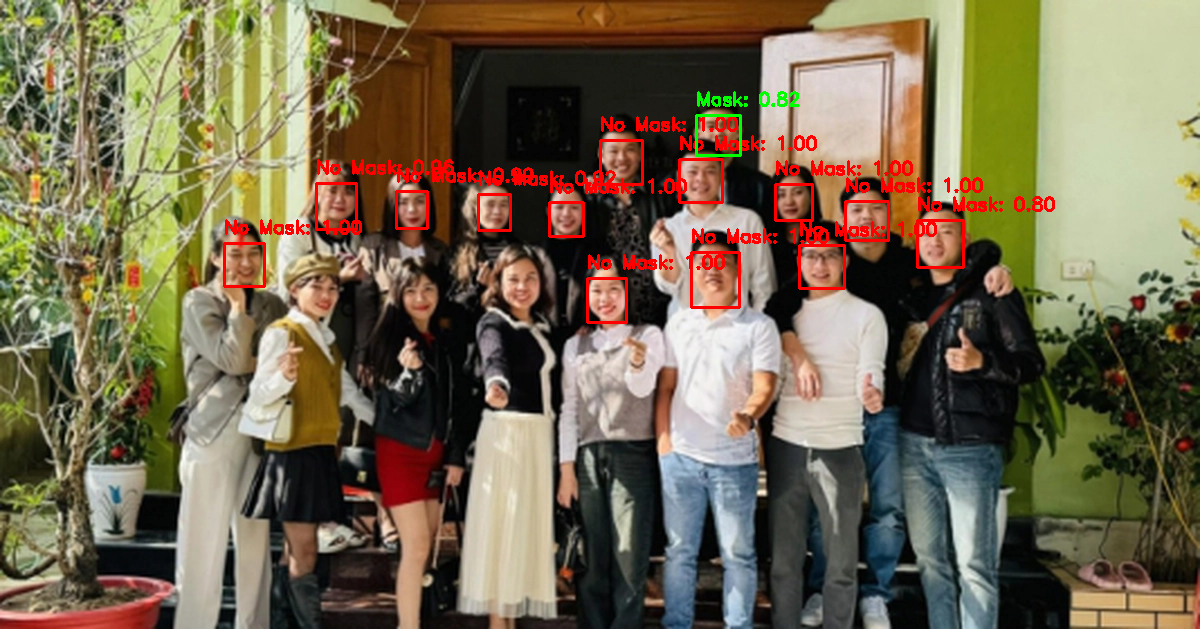

In [20]:
import cv2
import numpy as np
import tensorflow as tf
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from google.colab import files

yolo_model = YOLO('/content/drive/MyDrive/yolov8_best_mask.pt')
mobilenet_model = tf.keras.models.load_model('/content/drive/MyDrive/production_facemask_model.keras')
print("Đã load xong 2 mô hình thành công!")

print("\n=> HÃY UPLOAD MỘT TẤM ẢNH ĐÁM ĐÔNG ĐỂ TEST:")
uploaded_img = files.upload()
test_img_path = list(uploaded_img.keys())[0]

img = cv2.imread(test_img_path)
results = yolo_model(img, conf=0.4)[0]

for box in results.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    face_crop = img[y1:y2, x1:x2]
    if face_crop.size == 0: continue

    face_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
    face_resized = cv2.resize(face_rgb, (224, 224))
    face_array = tf.expand_dims(tf.keras.preprocessing.image.img_to_array(face_resized), 0)

    prediction = mobilenet_model.predict(face_array, verbose=0)[0][0]

    if prediction > 0.5:
        label, color = f"No Mask: {prediction:.2f}", (0, 0, 255)
    else:
        label, color = f"Mask: {1-prediction:.2f}", (0, 255, 0)

    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

cv2_imshow(img)